# Parte 3: Entrenamiendo y ejecución de modelo por el Método 3

En este código se va a entrenar el modelo usando los datos originales ya filtrados en la parte 2 y mediante capas convolucionales, de pooling, de normalización, de dropout, flatten y red neuronal artificial simple.

In [1]:
#Importación de las librerías necesarias
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout, BatchNormalization

from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
import gc
import os
import multiprocessing

Leemos el archivo de Películas con imagen, el cual obtuvimos en la parte 2 del preprocesamiento.

In [2]:
with open('C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Películas con imagen.csv', encoding='utf-8') as f:
        movies = pd.read_csv(f, sep=',')

In [3]:
movies.sample(5)

,index,imdbID,Genre,Poster,Action,Adventure,Animation,Comedy,Crime,Drama,Family,Fantasy,Horror,Music,Mystery,Romance,Sci-Fi,Sport,Thriller,Existe
15747,15842,tt0107852,Drama,https://m.media-amazon.com/images/M/MV5BMTg3MT...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
11315,11391,tt0093583,"Crime,Drama",https://m.media-amazon.com/images/M/MV5BMTYzNj...,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1
42454,42783,tt7600054,Drama,https://m.media-amazon.com/images/M/MV5BNWMzYW...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1
4705,4753,tt0068152,"Comedy,Crime,Drama",https://m.media-amazon.com/images/M/MV5BMGM0Zm...,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,1
20980,21114,tt0143344,"Action,Drama",https://m.media-amazon.com/images/M/MV5BMDk0Ym...,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1


In [5]:
print(movies.shape)

(47756, 20)


Vamos a buscar el archivo .jpg de cada película para ingresarla a una lista de imágenes.

In [6]:
#Definimos el array donde se van a ir guardando las imágenes
imagenes = []
# Imprimir los nombres de los archivos
for i in tqdm(range(movies.shape[0])):
    archivo = movies['imdbID'][i]
    path = "C:/Users/clau_/OneDrive/Documentos/FCFM/03_Tetramestre/Aprendizaje_Profundo/PIA/Posters/" + archivo + '.jpg'
    #Leemos la imagen
    imagen = image.load_img(path, target_size=(250, 250))
    imagen = image.img_to_array(imagen)
    imagen = imagen / 255
    #Agregamos la imagen a la lista de imágenes
    imagenes.append(imagen)

100%|██████████| 47756/47756 [02:07<00:00, 373.72it/s]


Las imágenes las ingresamos en el array que conforma las x, que será la variable dependiente. Este será un array de 4 dimensiones.

In [8]:
x = np.array(imagenes)

In [9]:
x.shape

(47756, 250, 250, 3)

In [10]:
#Borramos el array de imágenes para liberar espacio en RAM
del imagenes

Validamos que el índice corresponda a la imagen y su asignación.

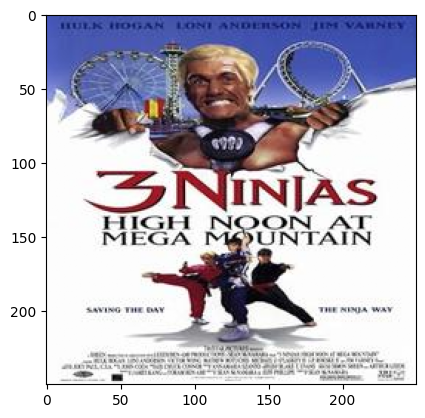

In [11]:
plt.imshow(x[18720])

In [12]:
movies.iloc[18720]

index                                                    18838
imdbID                                               tt0118539
Genre                                  Action,Adventure,Comedy
Poster       https://m.media-amazon.com/images/M/MV5BY2IzOT...
Action                                                       1
Adventure                                                    1
Animation                                                    0
Comedy                                                       1
Crime                                                        0
Drama                                                        0
Family                                                       0
Fantasy                                                      0
Horror                                                       0
Music                                                        0
Mystery                                                      0
Romance                                                

Una vez validado, se inserta en la variable y lo correspondiente a solo las columnas de los géneros, que son 15. Eliminamos las columnas que no nos sirven.

In [13]:
#Ahora con las y
y = movies.drop(columns = ['imdbID', 'Genre', 'Poster', 'Existe', 'index'])
y = y.to_numpy()
print(y.shape), print(type(y))

(47756, 15)
<class 'numpy.ndarray'>


(None, None)

# Entrenamiento del modelo

Realizamos el split de entrenamiento y prueba con un 80-20.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state = 0, test_size = 0.20)

In [15]:
#Borramos la x para liberar espacio en RAM
del x

In [16]:
X_train[0].shape

(250, 250, 3)

Vamos a definir las capas del modelo.

In [17]:
#Modelo secuencial
model = Sequential()
#Primera capa convolucional
model.add(Conv2D(16, (3, 3), activation='relu', input_shape= (250, 250, 3)))
#Primera capa de normalización
model.add(BatchNormalization())
#Primera capa de pooling
model.add(MaxPool2D(2,2))
#Primera capa de dropout
model.add(Dropout(0.3))

#Segunda capa convolucional
model.add(Conv2D(32, (3, 3), activation='relu'))
#Segunda capa de normalización
model.add(BatchNormalization())
#Segunda capa de pooling
model.add(MaxPool2D(2,2))
#Segunda capa de dropout
model.add(Dropout(0.3))

#Tercera capa convolucional
model.add(Conv2D(64, (3, 3), activation='relu'))
#Tercera capa de normalización
model.add(BatchNormalization())
#Tercera capa de pooling
model.add(MaxPool2D(2,2))
#Tercera capa de dropout
model.add(Dropout(0.3))

#Cuarta capa convolucional
model.add(Conv2D(128, (3, 3), activation='relu'))
#Cuarta capa de normalización
model.add(BatchNormalization())
#Cuarta capa de pooling
model.add(MaxPool2D(2,2))
#Cuarta capa de dropout
model.add(Dropout(0.3))

#Capa de aplanado
model.add(Flatten())

#Primera capa de ANN
model.add(Dense(64, activation='relu'))
#Quinta capa de normalización
model.add(BatchNormalization())
#Quinta capa de dropout
model.add(Dropout(0.3))

#Segunda capa de ANN
model.add(Dense(128, activation='relu'))
#Sexta capa de normalización
model.add(BatchNormalization())
#Sexta capa de dropout
model.add(Dropout(0.3))
#Capa de salida de ANN
model.add(Dense(15, activation='sigmoid'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 248, 248, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 248, 248, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 124, 124, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 122, 122, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 61, 61, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 59, 59, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 59, 59, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,384,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,493,935 (5.70 MB)

 Trainable params: 1,493,071 (5.70 MB)

 Non-trainable params: 864 (3.38 KB)

In [18]:
#Limpiamos para liberar espacio en RAM
gc.collect()

182

In [19]:
#Función para que cuando acabe el epoch se limpie el kernel
class GarbageCollectorCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

Se configuran para el modelo el término temprano para evitar sobreajuste, la limpieza de la basura del kernel y ajustar el learning rate de la propagación hacia atrás si es necesario por cada epoch.

In [20]:
#Se compila el modelo
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')
es_callback = EarlyStopping(monitor='val_loss', patience=3)
gc_callback = GarbageCollectorCallback()
lr_callback = ReduceLROnPlateau(monitor = 'val_loss', factor=0.1, patience=5, min_lr=0.0001)

In [21]:
#Se entrena el modelo
history = model.fit(X_train, y_train, epochs=15, validation_split=0.3, callbacks=[es_callback, gc_callback, lr_callback])

Epoch 1/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 926s 1s/step - accuracy: 0.1847 - loss: 0.5430 - val_accuracy: 0.2815 - val_loss: 0.3316 - learning_rate: 0.0010
Epoch 2/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 877s 1s/step - accuracy: 0.3042 - loss: 0.3260 - val_accuracy: 0.2965 - val_loss: 0.3147 - learning_rate: 0.0010
Epoch 3/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 747s 894ms/step - accuracy: 0.3133 - loss: 0.3192 - val_accuracy: 0.2933 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 4/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 731s 875ms/step - accuracy: 0.3269 - loss: 0.3138 - val_accuracy: 0.2885 - val_loss: 0.3122 - learning_rate: 0.0010
Epoch 5/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 769s 920ms/step - accuracy: 0.3315 - loss: 0.3082 - val_accuracy: 0.3006 - val_loss: 0.3120 - learning_rate: 0.0010
Epoch 6/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 769s 920ms/step - accuracy: 0.3356 - loss: 0.3073 - val_accuracy: 0.3052 - val_loss: 0.3098 - learning_rate: 0.0010
Epoch 7/15
836/836 ━━━━━━━━━━━━━━━━━━━━ 762s 911ms/step - accuracy: 0.

Una vez entrenado el modelo, vamos a hacer la predición del 20% de prueba.

In [30]:
pred = model.predict(X_test)

299/299 ━━━━━━━━━━━━━━━━━━━━ 49s 163ms/step


Comparamos los valores de Accuracy y Loss versus Val_Accuracy y Val_loss

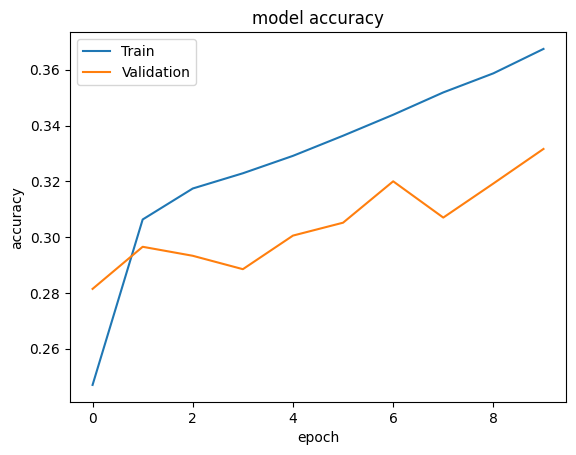

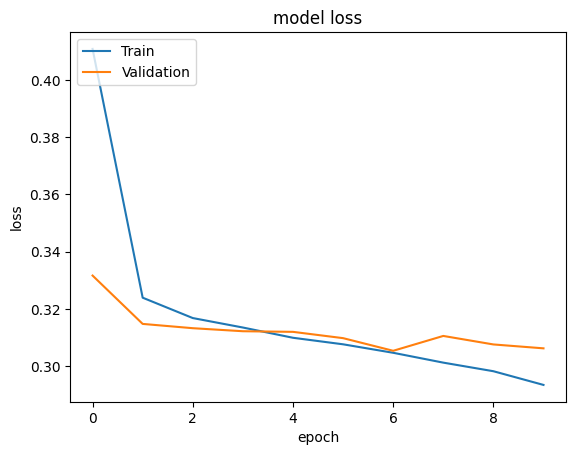

In [31]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Por último, calculamos las métricas para la comparativa.

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, hamming_loss, jaccard_score

In [36]:
#Arriba del 10% de probabilidad, se toma como éxito
umbral = 0.1
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.0039782244556113905
Precisión (Precision) - Micro: 0.2546170893868505
Precisión (Precision) - Macro: 0.21788831542907605
Recuperación (Recall) - Micro: 0.7544479991019812
Recuperación (Recall) - Macro: 0.5411308190221297
F1-Score - Micro: 0.3807392720577822
F1-Score - Macro: 0.28540796133137397
Pérdida de Hamming (Hamming Loss): 0.305178671133445
Jaccard Score (Coefficient): 0.25067082496416665


In [37]:
#Arriba del 20% de probabilidad, se toma como éxito
umbral = 0.2
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.04930904522613065
Precisión (Precision) - Micro: 0.36756736127013206
Precisión (Precision) - Macro: 0.30809485471148434
Recuperación (Recall) - Micro: 0.5405511590054443
Recuperación (Recall) - Macro: 0.2993139481648949
F1-Score - Micro: 0.43758377064449444
F1-Score - Macro: 0.24484849618572554
Pérdida de Hamming (Hamming Loss): 0.17278754885538805
Jaccard Score (Coefficient): 0.32285098608119966


In [38]:
#Arriba del 30% de probabilidad, se toma como éxito
umbral = 0.3
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.1286641541038526
Precisión (Precision) - Micro: 0.4525057530043467
Precisión (Precision) - Macro: 0.3629870951175766
Recuperación (Recall) - Micro: 0.3973171689959028
Recuperación (Recall) - Macro: 0.18396187966246835
F1-Score - Micro: 0.4231194524969367
F1-Score - Macro: 0.18914334823997472
Pérdida de Hamming (Hamming Loss): 0.13472222222222222
Jaccard Score (Coefficient): 0.33829655885246335


In [39]:
#Arriba del 40% de probabilidad, se toma como éxito
umbral = 0.4
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.16122278056951425
Precisión (Precision) - Micro: 0.5179870453413055
Precisión (Precision) - Macro: 0.3583893104859613
Recuperación (Recall) - Micro: 0.2917438401526632
Recuperación (Recall) - Macro: 0.11525060385913578
F1-Score - Micro: 0.37325865287950594
F1-Score - Macro: 0.13168471267837814
Pérdida de Hamming (Hamming Loss): 0.12183137911781128
Jaccard Score (Coefficient): 0.30792815765334614


In [40]:
#Arriba del 50% de probabilidad, se toma como éxito
umbral = 0.5
y_pred_binarizado = np.where(pred > umbral, 1, 0)
# Exactitud (Accuracy)
accuracy = accuracy_score(y_test, y_pred_binarizado)
print("Exactitud (Accuracy):", accuracy)

# Precisión (Precision)
precision_micro = precision_score(y_test, y_pred_binarizado, average='micro')
print("Precisión (Precision) - Micro:", precision_micro)

precision_macro = precision_score(y_test, y_pred_binarizado, average='macro')
print("Precisión (Precision) - Macro:", precision_macro)

# Recuperación (Recall o Sensibilidad)
recall_micro = recall_score(y_test, y_pred_binarizado, average='micro')
print("Recuperación (Recall) - Micro:", recall_micro)

recall_macro = recall_score(y_test, y_pred_binarizado, average='macro')
print("Recuperación (Recall) - Macro:", recall_macro)

# F1-Score
f1_micro = f1_score(y_test, y_pred_binarizado, average='micro')
print("F1-Score - Micro:", f1_micro)

f1_macro = f1_score(y_test, y_pred_binarizado, average='macro')
print("F1-Score - Macro:", f1_macro)

# Pérdida de Hamming (Hamming Loss)
hamming_loss_val = hamming_loss(y_test, y_pred_binarizado)
print("Pérdida de Hamming (Hamming Loss):", hamming_loss_val)

# Jaccard Score (Coefficient)
jaccard_score_val = jaccard_score(y_test, y_pred_binarizado, average='samples')
print("Jaccard Score (Coefficient):", jaccard_score_val)

Exactitud (Accuracy): 0.14080820770519262
Precisión (Precision) - Micro: 0.5647660598766361
Precisión (Precision) - Macro: 0.30058769276400404
Recuperación (Recall) - Micro: 0.21069764831340854
Recuperación (Recall) - Macro: 0.07516142067173023
F1-Score - Micro: 0.3068999345977763
F1-Score - Macro: 0.09138411651799293
Pérdida de Hamming (Hamming Loss): 0.11834170854271357
Jaccard Score (Coefficient): 0.24257809384222698


Definimos el umbral con el F1 más alto e imprimimos un ejemplo aleatorio.

In [45]:
umbral = 0.2
y_pred_binarizado = np.where(pred > umbral, 1, 0)

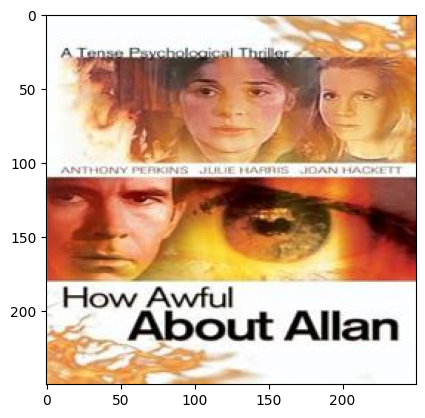

In [46]:
plt.imshow(X_test[1235])

In [47]:
print(y_test[1235])

[0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]


In [50]:
print(y_pred_binarizado[1235])

[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]
